(array([135061.,  77920., 123109., 145949., 145204., 142272., 142745.,
        148258., 160945., 273577.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

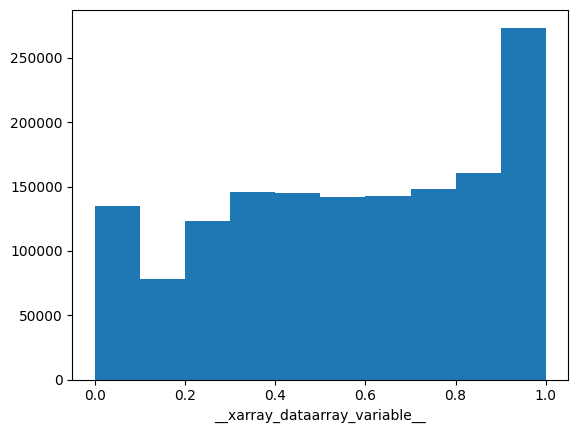

In [7]:
import xarray
import numpy as np
import netCDF4


# open a val dataset
ds = xarray.open_dataset('/Users/hzorkic/CI2026-StarterKit/data/train_data/val_target_aimip_region1.nc')

ds

# plot

ds.__xarray_dataarray_variable__.plot()


<xarray.Dataset> Size: 7GB
Dimensions:          (vars_aux: 8, lat: 64, lon: 64, time: 14610,
                      vars_level: 4, level: 7)
Coordinates:
  * vars_aux         (vars_aux) <U23 736B 'land_sea_mask' ... 'type_of_high_v...
  * lat              (lat) float64 512B -30.0 -28.5 -27.0 ... 61.5 63.0 64.5
  * lon              (lon) float64 512B 300.0 301.5 303.0 ... 31.5 33.0 34.5
  * time             (time) datetime64[ns] 117kB 1979-01-01 ... 2018-12-31
  * vars_level       (vars_level) <U3 48B 'ta' 'hus' 'ua' 'va'
  * level            (level) int64 56B 1000 850 700 500 250 100 50
Data variables:
    input_auxiliary  (vars_aux, lat, lon) float32 131kB ...
    input_level      (time, vars_level, level, lat, lon) float32 7GB ...
    target           (time, lat, lon) float32 239MB ...

<xarray.DataArray 'input_auxiliary' (lat: 64, lon: 64)> Size: 16kB
[4096 values with dtype=float32]
Coordinates:
  * lat       (lat) float64 512B -30.0 -28.5 -27.0 -25.5 ... 60.0 61.5 63.0 64.5
  * lon       (lon) float64 512B 300.0 301.5 303.0 304.5 ... 30.0 31.5 33.0 34.5
    vars_aux  <U23 92B 'land_sea_mask' <xarray.DataArray 'input_auxiliary' (lat: 64, lon: 64)> Size: 16kB
[4096 values with dtype=float32]
Coordinates:
  * lat       (lat) float64 512B -30.0 -28.5 -27.0 -25.5 ... 60.0 61.5 63.0 64.5
  * lon       (lon) float64 512B 300.0 301.5 303.0 304.5 ... 30.0 31.5 33.0 34.5
    vars_aux  <U23 92B 'geopotential_at_surface' <xarray.DataArray 'input_auxiliary' (lat: 64, lon: 64)> Size: 16kB
[4096 values with dtype=float32]
Coordinates:
  * lat       (lat) float64 512B -30.0 -28.5 -27.0 -25.5 ... 60.0 61.5 63.0 64.5
  * lon       (lon) float64 512B 300.0 301.5 303.0 304.5 ... 30.0 31.5 33.0 34.5
    vars_aux  <U23 92B 'lake_cover' <xarray.DataArray 'input_auxiliary' (lat: 64, lon: 

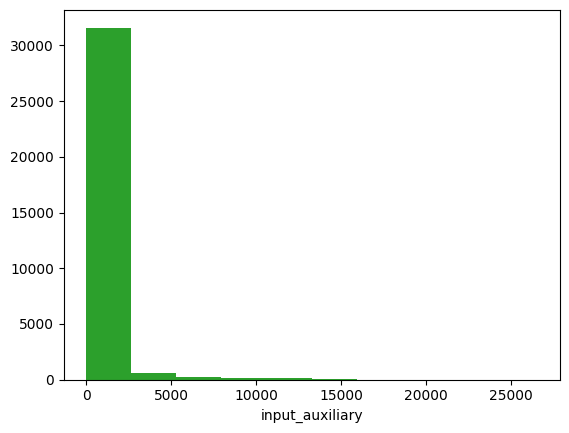

In [17]:
import xarray
import numpy as np
import netCDF4


# open a val dataset
ds = xarray.open_dataset('/Users/hzorkic/CI2026-StarterKit/data/train_data/train.zarr')

display(ds)

# plot

for var in ds.data_vars:
    print(*ds.input_auxiliary)
    print(ds.input_auxiliary.plot())
    
 


In [2]:
import torch
import xarray as xr
 
from starter_kit.baselines.utils import estimate_relative_humidity
 
df = xr.open_zarr(store='../data/train_data/train.zarr')
input_level = torch.from_numpy(df.input_level.values)
print(input_level.shape)
pressure_levels = input_level[:, 0, :, 0, 0]
L = input_level.shape[2]
H, W = input_level.shape[-2:]
B = input_level.shape[0]
pressure = pressure_levels.view(B, L, 1, 1).expand(B, L, H, W)
 
level_rh = estimate_relative_humidity(
    temperature=input_level[:, 0],
    specific_humidity=input_level[:, 1],
    pressure=pressure
)
print(level_rh.shape)
stds = []
means = []
for i in range(0, 7):
    sliced = level_rh[:, i, :, :]
    print(sliced.shape)
    stds.append(torch.std(sliced, dim=[0,1,2], keepdim=True))
    means.append(torch.mean(sliced, dim=[0,1,2], keepdim=True))
 
print(*stds)
print(*means)
   

torch.Size([14610, 4, 7, 64, 64])
torch.Size([14610, 7, 64, 64])
torch.Size([14610, 64, 64])
torch.Size([14610, 64, 64])
torch.Size([14610, 64, 64])
torch.Size([14610, 64, 64])
torch.Size([14610, 64, 64])
torch.Size([14610, 64, 64])
torch.Size([14610, 64, 64])
tensor([[[0.0006]]]) tensor([[[0.0008]]]) tensor([[[0.0010]]]) tensor([[[0.0014]]]) tensor([[[0.0017]]]) tensor([[[0.0036]]]) tensor([[[0.0007]]])
tensor([[[0.0020]]]) tensor([[[0.0020]]]) tensor([[[0.0018]]]) tensor([[[0.0020]]]) tensor([[[0.0030]]]) tensor([[[0.0040]]]) tensor([[[0.0009]]])


In [4]:
# print the means as a list of floats, 6 decim
print([round(float(mean), 6) for mean in means])

[0.001953, 0.001983, 0.001815, 0.001981, 0.002994, 0.004023, 0.000892]


In [5]:
# print the std as a list of floats, 6 decim
print([round(float(std), 6) for std in stds])

[0.000637, 0.000847, 0.000996, 0.001389, 0.001727, 0.003555, 0.000679]


In [2]:
import xarray
import numpy as np
import netCDF4


# open a val dataset
ds = xarray.open_dataset('/Users/hzorkic/CI2026-StarterKit/data/train_data/train.zarr')

print(ds)


<xarray.Dataset> Size: 7GB
Dimensions:          (vars_aux: 8, lat: 64, lon: 64, time: 14610,
                      vars_level: 4, level: 7)
Coordinates:
  * vars_aux         (vars_aux) <U23 736B 'land_sea_mask' ... 'type_of_high_v...
  * lat              (lat) float64 512B -30.0 -28.5 -27.0 ... 61.5 63.0 64.5
  * lon              (lon) float64 512B 300.0 301.5 303.0 ... 31.5 33.0 34.5
  * time             (time) datetime64[ns] 117kB 1979-01-01 ... 2018-12-31
  * vars_level       (vars_level) <U3 48B 'ta' 'hus' 'ua' 'va'
  * level            (level) int64 56B 1000 850 700 500 250 100 50
Data variables:
    input_auxiliary  (vars_aux, lat, lon) float32 131kB ...
    input_level      (time, vars_level, level, lat, lon) float32 7GB ...
    target           (time, lat, lon) float32 239MB ...

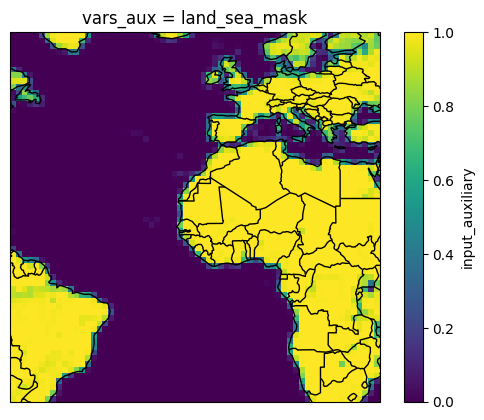

In [35]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

da = ds.input_auxiliary.isel(vars_aux=0)
da = da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
da.plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS)


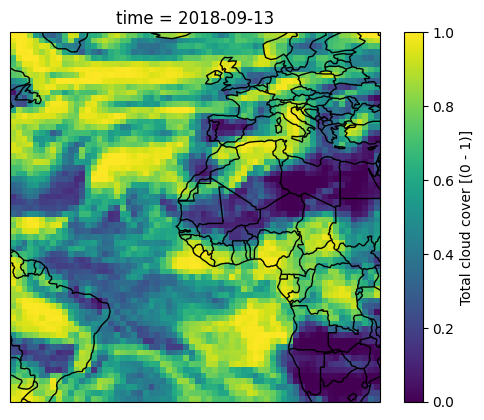

In [31]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt


da = ds.target.isel(time=14500)
da = da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
da.plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS)

/Users/hzorkic/miniforge3/envs/ci26_starter_kit/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


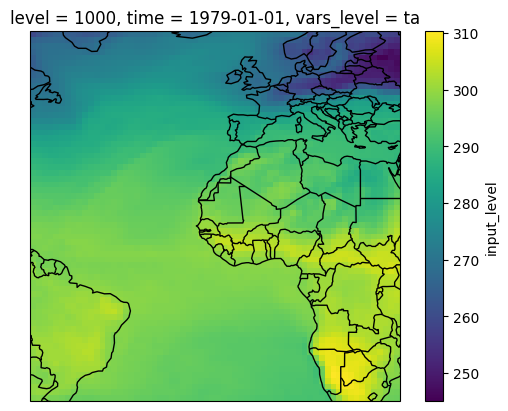

In [23]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

da = ds.input_level.isel(time=0, vars_level=0, level=0)
da = da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
da.plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
